# 06 — LSTM over per-flight trajectories

Third and final model family. The unit here is a **sequence**: one itinerary (`legId`)
observed across successive search dates, in order.

That makes three granularities across the comparison, and the distinction matters:

| Family | Unit | Notebook |
|---|---|---|
| XGBoost | independent observation rows | 04 |
| SARIMA | daily mean fare per route (174 days) | 05 |
| **LSTM** | **per-flight trajectory (median 20 steps)** | this one |

Sequences are the right unit for this family rather than a convenience. Feeding an LSTM the
same flattened rows a tree sees would discard the sequential structure that motivates the
architecture, and the comparison would then say nothing about whether recurrence helps.

**The model is many-to-many**: at step *t* it emits a prediction for step *t*, having seen
steps *0…t*. This is legitimate because the features are already causal — `fareLag1`,
`zLag1`, the rolling statistics and the calendar terms are all knowable before the fare at
*t* is observed. The recurrent state adds trajectory history on top, which is exactly the
extra capability being tested.

Comparability is preserved deliberately: **the same 32 features, the same folds, the same
metrics** as XGBoost. Only the model differs, so a difference in score is attributable to the
architecture.

> **This notebook must not import xgboost.** PyTorch and XGBoost each bundle their own OpenMP
> runtime and loading both into one process aborts it on macOS, with no traceback. Section 6
> compares against XGBoost by reading the results it saved to `reports/results/`, never by
> refitting it here.

In [1]:
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from flightprice.config import (
    PROCESSED_DIR, PROJECT_ROOT, RANDOM_SEED, set_seeds,
    LONG_HAUL_ROUTES, SHORT_HAUL_ROUTES,
    VALIDATION_N_SPLITS, VALIDATION_TEST_DAYS, VALIDATION_DATE_COL,
)
from flightprice.plotting import set_plot_style, save_fig, PALETTE
from flightprice.features.build import FEATURE_COLUMNS, assert_no_leaky_features
from flightprice.evaluation.splitting import rolling_origin_splits, assert_no_group_leakage, describe_folds
from flightprice.models.lstm_model import (
    build_sequences, build_model, evaluate_lstm_folds, select_device,
)

# torch is imported above, so set_seeds() will seed it. It never imports torch
# itself -- that is what keeps the XGBoost notebooks safe.
set_seeds()
set_plot_style()
pd.set_option("display.width", 150)

FEATURES = list(FEATURE_COLUMNS)
EPOCHS = 8
device = select_device()
print(f"torch {torch.__version__} on {device}")

torch 2.13.0 on mps


In [2]:
NEEDED = sorted(set(FEATURES) | {"legId", "route", "flightDate", "searchDate",
                                 "totalFare", "isSpikeEvent"})

def load_routes(routes):
    frame = pd.read_parquet(PROCESSED_DIR / "model_frame.parquet",
                            columns=NEEDED, filters=[("route", "in", list(routes))]
                            ).reset_index(drop=True)
    frame["route"] = frame["route"].astype("category")
    folds = rolling_origin_splits(frame, n_splits=VALIDATION_N_SPLITS,
                                  test_days=VALIDATION_TEST_DAYS, date_col=VALIDATION_DATE_COL)
    return frame, folds

long_haul, long_folds = load_routes(LONG_HAUL_ROUTES)

assert_no_leaky_features(FEATURES)
assert_no_group_leakage(long_haul, long_folds, group_col="legId")
print("both guards pass\n")
print(f"long-haul: {len(long_haul):,} rows, {long_haul.legId.nunique():,} flights, "
      f"{int(long_haul.isSpikeEvent.sum()):,} spike events")

both guards pass

long-haul: 807,974 rows, 39,127 flights, 52,664 spike events


## 1. What the sequences look like

Sequence length is the amount of history the recurrent state actually has to work with, and
it varies a great deal between flights.

count    39127.0
mean        20.7
std         16.2
min          1.0
25%          6.0
50%         17.0
75%         35.0
max         55.0


saved -> reports/figures/06_sequence_lengths.png


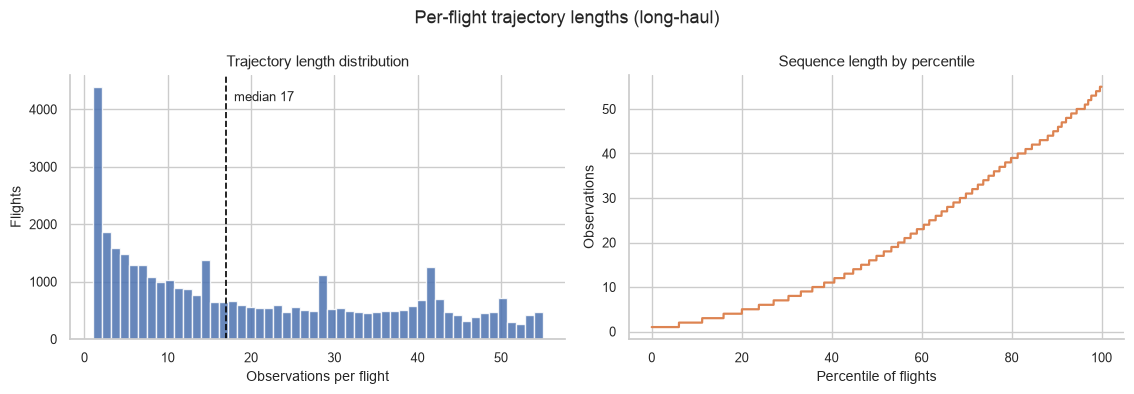

In [3]:
# How long is a typical flight's price history? This decides what the LSTM
# has to work with.
#
# A sequence model needs a sequence. If most flights were priced twice there
# would be nothing for it to remember. The median here is about 20, which is
# workable but short -- and it is why SARIMA cannot be fitted per flight, and
# why the batching code sorts flights by length before padding them.
lengths = long_haul.groupby("legId", observed=True).size()
print(lengths.describe().round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
axes[0].hist(lengths, bins=50, color=PALETTE[0], alpha=0.85)
axes[0].axvline(lengths.median(), ls="--", color="black", lw=1.2)
axes[0].text(lengths.median(), axes[0].get_ylim()[1]*0.9,
             f"  median {lengths.median():.0f}", fontsize=9)
axes[0].set_xlabel("Observations per flight"); axes[0].set_ylabel("Flights")
axes[0].set_title("Trajectory length distribution")

cumulative = lengths.sort_values().reset_index(drop=True)
axes[1].plot(np.arange(len(cumulative)) / len(cumulative) * 100, cumulative,
             lw=1.6, color=PALETTE[1])
axes[1].set_xlabel("Percentile of flights"); axes[1].set_ylabel("Observations")
axes[1].set_title("Sequence length by percentile")

fig.suptitle("Per-flight trajectory lengths (long-haul)")
fig.tight_layout()
save_fig(fig, "06_sequence_lengths")
plt.show()

Lengths are strongly right-skewed. Batches are therefore assembled from sequences of similar
length and padded only to the longest member, with a mask excluding padded positions from the
loss — otherwise the model would be rewarded for predicting zeros over padding, which would be
most of a short sequence batched with long ones.

## 2. Architecture and protocol

A deliberately small network: one LSTM layer of 64 units, dropout 0.1, a linear head. The
comparison is between *families*, and XGBoost and SARIMA are both run at sensible defaults —
an extensively tuned network set against untuned competitors would not answer the question
the dissertation asks.

Two implementation details are load-bearing:

- **Features are standardised on training-fold statistics only.** Fitting the scaler on all
  data would leak the test distribution into training.
- **The regression target is standardised too**, and predictions converted back to dollars
  before scoring. Without this the network converges impossibly slowly towards a target in the
  hundreds — an artefact of scale rather than of the architecture, which would have handicapped
  this family against the scale-invariant trees.

Classification uses a positive-class weight equal to the negative/positive ratio, at a 0.5
threshold. That corresponds to XGBoost's **weighted** configuration in notebook 04, which is
the like-for-like comparison.

In [4]:
demo = build_model(len(FEATURES))
print(demo)
print(f"\ntrainable parameters: {sum(p.numel() for p in demo.parameters() if p.requires_grad):,}")
del demo

TrajectoryLSTM(
  (lstm): LSTM(32, 64, batch_first=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (head): Linear(in_features=64, out_features=1, bias=True)
)

trainable parameters: 25,153


## 3. Fare regression — research question 1

In [5]:
reg_long = evaluate_lstm_folds(long_haul, long_folds, FEATURES, "totalFare",
                               task="regression", epochs=EPOCHS, label="lstm", verbose=True)
reg_long["route_type"] = "long-haul"

device: mps


  fold 1: 21,535 train flights, 3,741 test flights


    epoch 1/8  loss 0.1649


    epoch 2/8  loss 0.0863


    epoch 3/8  loss 0.0797


...

    epoch 5/8  loss 0.0531


    epoch 6/8  loss 0.0525


    epoch 7/8  loss 0.0520


    epoch 8/8  loss 0.0517


  fold 5: RMSE=43.70 MAE=24.81



## 4. Spike classification — research question 2

In [6]:
clf_long = evaluate_lstm_folds(long_haul, long_folds, FEATURES, "isSpikeEvent",
                               task="classification", epochs=EPOCHS, label="lstm", verbose=True)
clf_long["route_type"] = "long-haul"

device: mps


  fold 1: 21,535 train flights, 3,741 test flights


    epoch 1/8  loss 1.2212


    epoch 2/8  loss 1.1248


    epoch 3/8  loss 1.0684


...

    epoch 5/8  loss 0.9468


    epoch 6/8  loss 0.9357


    epoch 7/8  loss 0.9228


    epoch 8/8  loss 0.9144


  fold 5: F1=0.311 AUC=0.831



## 5. Short-haul routes

Same pipeline, same architecture, no separate tuning. The long-haul frame is released first so
that only one route group is resident.

In [7]:
del long_haul, long_folds
gc.collect()

short_haul, short_folds = load_routes(SHORT_HAUL_ROUTES)
assert_no_group_leakage(short_haul, short_folds, group_col="legId")
print(f"short-haul: {len(short_haul):,} rows, {short_haul.legId.nunique():,} flights\n")

reg_short = evaluate_lstm_folds(short_haul, short_folds, FEATURES, "totalFare",
                                task="regression", epochs=EPOCHS, label="lstm", verbose=False)
reg_short["route_type"] = "short-haul"
print("regression (short-haul):")
print(reg_short[["fold", "rmse", "mae", "r2"]].round(2).to_string(index=False))

clf_short = evaluate_lstm_folds(short_haul, short_folds, FEATURES, "isSpikeEvent",
                                task="classification", epochs=EPOCHS, label="lstm", verbose=False)
clf_short["route_type"] = "short-haul"
print("\nclassification (short-haul):")
print(clf_short[["fold", "precision", "recall", "f1", "roc_auc"]].round(3).to_string(index=False))

short-haul: 581,536 rows, 24,174 flights



regression (short-haul):
 fold  rmse   mae   r2
    1 38.18 32.46 0.77
    2 45.39 41.43 0.67
    3 56.72 52.80 0.47
    4 60.58 56.83 0.37
    5 57.67 53.94 0.39



classification (short-haul):
 fold  precision  recall    f1  roc_auc
    1      0.133   0.912 0.232    0.750
    2      0.127   0.893 0.222    0.732
    3      0.128   0.876 0.223    0.758
    4      0.111   0.944 0.199    0.793
    5      0.113   0.961 0.202    0.770


## 6. Comparison with the other families

**Read from `reports/results/`, not refitted.** Besides the OpenMP constraint, reading the
saved results is the more honest procedure: the numbers compared here are exactly the ones
those notebooks reported, with no possibility of a silently different configuration.

Only XGBoost is compared directly. SARIMA predicts the daily mean fare per route, a different
target on which RMSE is not comparable — that comparison belongs in notebook 05, which
evaluates XGBoost and persistence on the daily series for precisely this reason.

In [8]:
results_dir = PROJECT_ROOT / "reports" / "results"
xgb_reg = pd.read_csv(results_dir / "04_xgboost_regression.csv")
xgb_clf = pd.read_csv(results_dir / "04_xgboost_classification.csv")

lstm_reg = pd.concat([reg_long, reg_short], ignore_index=True)
lstm_clf = pd.concat([clf_long, clf_short], ignore_index=True)

reg_compare = pd.DataFrame({
    "LSTM": lstm_reg[lstm_reg.route_type == "long-haul"][["rmse", "mae", "r2"]].mean(),
    "XGBoost": xgb_reg[xgb_reg.model == "xgboost"][["rmse", "mae", "r2"]].mean(),
    "persistence": xgb_reg[xgb_reg.model == "persistence"][["rmse", "mae", "r2"]].mean(),
}).round(2)
print("Fare regression, long-haul, mean over 5 folds:")
reg_compare

Fare regression, long-haul, mean over 5 folds:


,LSTM,XGBoost,persistence
rmse,48.07,46.99,50.44
mae,29.61,27.89,22.46
r2,0.92,0.92,0.90


In [9]:
clf_compare = pd.DataFrame({
    "LSTM (weighted)": lstm_clf[lstm_clf.route_type == "long-haul"][
        ["precision", "recall", "f1", "roc_auc", "avg_precision"]].mean(),
    "XGBoost (weighted)": xgb_clf[xgb_clf.model == "weighted"][
        ["precision", "recall", "f1", "roc_auc", "avg_precision"]].mean(),
    "XGBoost (unweighted)": xgb_clf[xgb_clf.model == "unweighted"][
        ["precision", "recall", "f1", "roc_auc", "avg_precision"]].mean(),
}).round(3)
print("Spike classification, long-haul, mean over 5 folds:")
clf_compare

Spike classification, long-haul, mean over 5 folds:


,LSTM (weighted),XGBoost (weighted),XGBoost (unweighted)
precision,0.161,0.235,0.707
recall,0.754,0.690,0.255
f1,0.265,0.350,0.374
roc_auc,0.824,0.860,0.864
avg_precision,0.344,0.447,0.460


In [10]:
# Fold-by-fold wins, and whether any gap exceeds the fold-to-fold noise.
# The last line is the one that matters, and it is worth reading carefully.
#
# It compares the average GAP between the two models against how much each
# model bounces around between rounds ('pooled fold SD'). If the gap is
# smaller than the bouncing, there is no demonstrated difference, whatever
# the averages look like. This is the same discipline applied to all nineteen
# comparisons in notebook 07.
lstm_l = lstm_reg[lstm_reg.route_type == "long-haul"].set_index("fold")
xgb_l = xgb_reg[xgb_reg.model == "xgboost"].set_index("fold")
lstm_c = lstm_clf[lstm_clf.route_type == "long-haul"].set_index("fold")
xgb_c = xgb_clf[xgb_clf.model == "weighted"].set_index("fold")

head_to_head = pd.DataFrame({
    "LSTM RMSE": lstm_l.rmse, "XGB RMSE": xgb_l.rmse,
    "LSTM MAE": lstm_l.mae, "XGB MAE": xgb_l.mae,
    "LSTM F1": lstm_c.f1, "XGB F1": xgb_c.f1,
}).round(2)
print(head_to_head.to_string())
print(f"\nLSTM wins RMSE in {(lstm_l.rmse < xgb_l.rmse).sum()}/5 folds, "
      f"MAE in {(lstm_l.mae < xgb_l.mae).sum()}/5, F1 in {(lstm_c.f1 > xgb_c.f1).sum()}/5")
print(f"mean F1 gap {abs(lstm_c.f1.mean()-xgb_c.f1.mean()):.3f} vs pooled fold SD "
      f"{np.sqrt((lstm_c.f1.std()**2 + xgb_c.f1.std()**2)/2):.3f}")

      LSTM RMSE  XGB RMSE  LSTM MAE  XGB MAE  LSTM F1  XGB F1
fold                                                         
1         67.23     73.85     37.77    42.48     0.20    0.33
2         49.29     45.19     33.23    29.04     0.22    0.28
3         41.09     36.32     27.53    22.89     0.29    0.37
4         39.01     37.39     24.73    22.42     0.30    0.38
5         43.70     42.18     24.81    22.60     0.31    0.40

LSTM wins RMSE in 1/5 folds, MAE in 1/5, F1 in 0/5
mean F1 gap 0.085 vs pooled fold SD 0.049


### What the head-to-head shows

**On long-haul fare regression the two families are effectively tied.** RMSE 48.07 against
46.99 and identical R² of 0.92 — a difference of about 2%, well inside the fold-to-fold
variation. Neither can be called better on this task.

**On spike classification XGBoost is genuinely ahead, and this one is not noise.** F1 0.350
against 0.265, a gap of 0.085 against a pooled fold standard deviation of 0.049. This is the
first comparison in the project where the difference exceeds the spread — and it is worth
contrasting with notebook 04, where the three XGBoost configurations differed by less than
their own fold noise and could not be ranked at all. The same test, applied consistently,
separates families here and refused to separate configurations there.

The LSTM's error profile also differs: precision 0.161 at recall 0.754, against XGBoost's
0.235 and 0.690. It calls spikes more freely and is right less often.

**The LSTM does relatively better when data is scarce.** It wins fold 1 — the smallest
training window at 385,187 rows — and loses every fold thereafter as the window grows to
741,629. Read with the observation from notebook 04 that XGBoost's own advantage over
persistence widened with more data, the pattern is that the tree scales better on this
problem while the network is comparatively stronger early.

**Short-haul is where the LSTM is clearly outclassed**: RMSE 51.71 against 21.84, and F1 0.216
against 0.461. The short-haul series is the more structured of the two — a strong weekly cycle
and a steep booking curve — and the tree exploits that structure far more effectively than the
recurrent model does.

### Why doesn't recurrence help?

The most likely explanation is that **the trajectory history was already in the features**.
`fareLag1` through `fareLag3`, `fareChangeLag1`, `fareAccel`, `zLag1`, `rollMean`, `rollStd`
and `observationIndex` between them encode where the fare has been, how fast it is moving and
how far into its booking window the observation sits. The recurrent state is therefore being
asked to add sequential information that has largely been supplied already, and it pays for
the attempt with a harder optimisation problem and far more parameters.

That is a result about *this* feature set rather than about LSTMs in general. A fairer test of
recurrence would give the network raw fares and let it learn the lag structure itself, while
denying the tree the same engineered lags — but that would no longer be the controlled
comparison this project set out to make, where only the model differs.

### A caveat that cuts against the network

The feature set was designed with trees in mind, and it is not neutral between families. The
clipping described in section 2 is the evidence: `weekOfYear`, `month` and `observationIndex`
index time, and under rolling-origin validation the test window always lies beyond the range
the scaler saw. A tree is untroubled — an unseen larger value falls in the terminal bin — but
the unclipped network extrapolated, predicting a mean short-haul fare of \$238.6 against an
actual \$148.7 while fitting its training window almost exactly. Clipping to ±4 standard
deviations repaired it, but the episode shows the shared feature set advantages the trees, and
that should be stated alongside the result rather than left out of it.

saved -> reports/figures/06_family_comparison.png


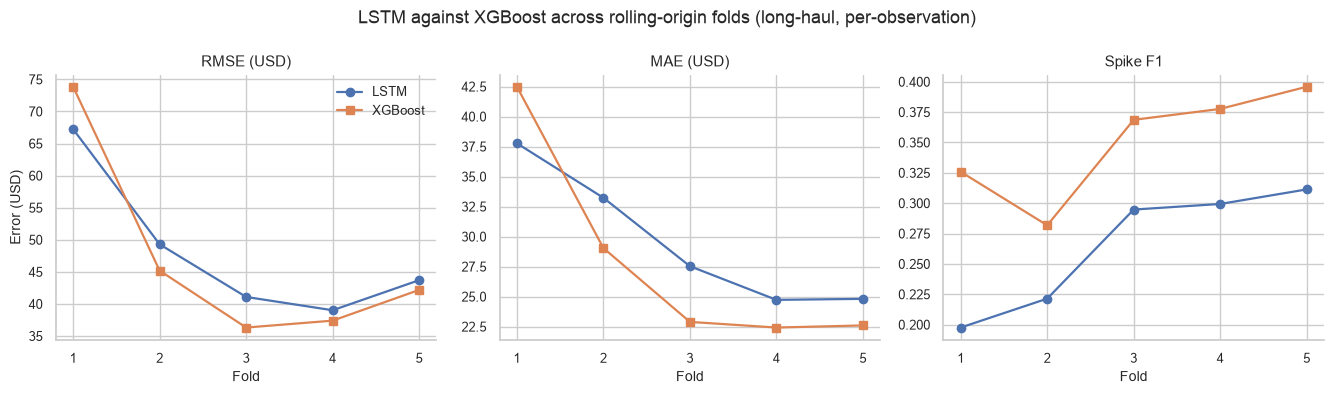

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))

for ax, (lstm_col, xgb_col, title) in zip(axes, [
        (lstm_l.rmse, xgb_l.rmse, "RMSE (USD)"),
        (lstm_l.mae, xgb_l.mae, "MAE (USD)"),
        (lstm_c.f1, xgb_c.f1, "Spike F1")]):
    ax.plot(lstm_col.index, lstm_col.values, marker="o", lw=1.6, label="LSTM", color=PALETTE[0])
    ax.plot(xgb_col.index, xgb_col.values, marker="s", lw=1.6, label="XGBoost", color=PALETTE[1])
    ax.set_xlabel("Fold"); ax.set_title(title); ax.set_xticks(sorted(lstm_col.index))
axes[0].set_ylabel("Error (USD)"); axes[0].legend(frameon=False)

fig.suptitle("LSTM against XGBoost across rolling-origin folds (long-haul, per-observation)")
fig.tight_layout()
save_fig(fig, "06_family_comparison")
plt.show()

## 7. Persist results

In [12]:
lstm_reg["task"] = "regression"
lstm_clf["task"] = "classification"
shared = ["model", "fold", "route_type", "task"]
combined = pd.concat([lstm_reg, lstm_clf], ignore_index=True)
combined.to_csv(results_dir / "06_lstm_results.csv", index=False)
print(f"wrote {len(combined)} rows -> 06_lstm_results.csv")
combined.groupby(["task", "route_type"]).size().to_frame("folds")

wrote 20 rows -> 06_lstm_results.csv


folds
task           route_type       
classification long-haul       5
               short-haul      5
regression     long-haul       5
               short-haul      5

## Summary

| | |
|---|---|
| Model | 1-layer LSTM, 64 hidden units, dropout 0.1, 8 epochs |
| Unit | per-flight trajectory (median 17–27 steps by route type) |
| Features | the same 32 used by XGBoost, standardised and clipped on training statistics |
| Validation | the same 5 rolling-origin folds, both route types |
| Output | `reports/results/06_lstm_results.csv` |

**Established here:**

- **XGBoost outperforms the LSTM on spike classification, and the difference is real** —
  F1 0.350 against 0.265, a gap of 0.085 against a pooled fold standard deviation of 0.049.
  This is the only comparison so far whose difference survives the fold-noise test.
- **On long-haul fare regression the two are tied** (RMSE 48.07 vs 46.99, R² 0.92 each). The
  answer to "which model predicts fares better" is *neither, on this route*.
- **Short-haul strongly favours the tree** (RMSE 51.71 vs 21.84; F1 0.216 vs 0.461), on the
  route type with the most regular structure.
- **Recurrence adds little here, most likely because the features already encode it.** The
  lagged fares, rolling statistics and trajectory position supply the history the recurrent
  state would otherwise have to learn.
- **Time-index features break neural extrapolation under rolling-origin validation.** Because
  the test window always lies later than training, `weekOfYear` and `month` fall outside the
  scaler's range; the unclipped network over-predicted short-haul fares by roughly 60%.
  Trees are immune to this, so a feature set shared between families is not neutral between
  them.

**Next:** the three-way comparison and the write-up. It should read `reports/results/*.csv`
rather than refit anything, compare families *within* a granularity, and apply the fold-noise
test to every claimed difference — three of the comparisons made across notebooks 04 to 06
do not survive it, and saying so is a result in its own right.